Simulating heterogeneous populations. This may take a moment...


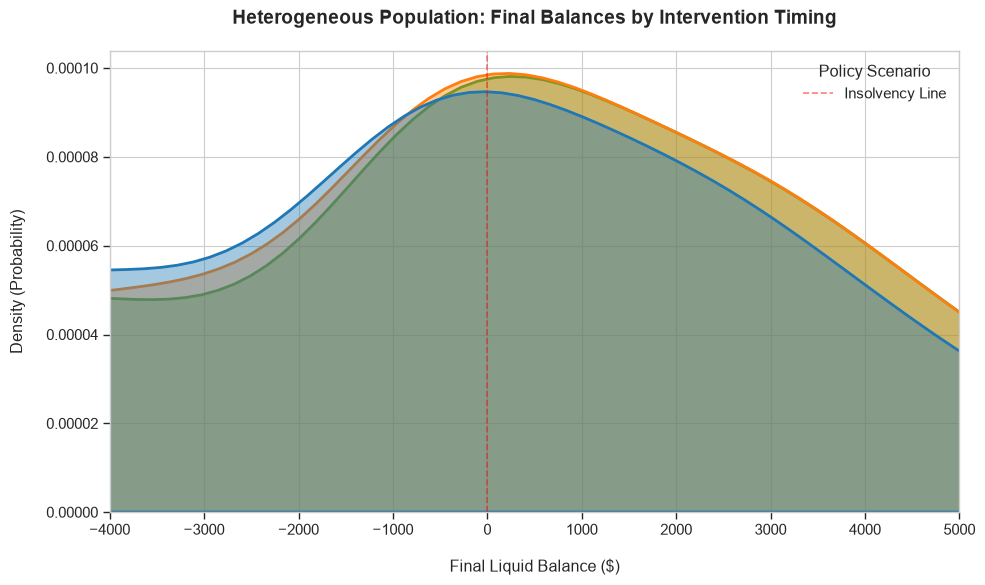

In [1]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from src.model.household import Household
from src.model.choice_set import Action, ChoiceSet
from src.model.simulation import Simulation
from src.model.intervention import Intervention

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

universal_actions = [
    Action("Pay in Full", 0.0, 0.1),
    Action("Min Payment", 50.0, 0.2),
    Action("Refinance", 10.0, 0.8),
    Action("Payday Loan", 150.0, 0.1)
]
choice_set = ChoiceSet(universal_actions)

iterations = 2000
results_data = []

print("Simulating heterogeneous populations. This may take a moment...")

for i in range(iterations):
    seed = random.randint(0, 100000)
    
    # Injecting variance into the household population
    rand_income = max(800.0, np.random.normal(1500.0, 300.0))
    rand_debt = max(0.0, np.random.normal(5000.0, 2000.0))
    rand_sensitivity = max(0.2, min(0.9, np.random.normal(0.6, 0.15)))
    
    def new_household():
        return Household(1000.0, rand_debt, 1200.0, rand_income, rand_sensitivity)
    
    # 1. Control
    sim_c = Simulation(new_household(), choice_set, 12, 0.3, -600.0, random_seed=seed)
    sim_c.run()
    results_data.append({"Scenario": "Control (None)", "Final Balance": sim_c.household.balance})
    
    # 2. Early Intervention
    sim_e = Simulation(new_household(), choice_set, 12, 0.3, -600.0, 
                       Intervention("Early", 600.0, 2), random_seed=seed)
    sim_e.run()
    results_data.append({"Scenario": "Early (Month 2)", "Final Balance": sim_e.household.balance})
    
    # 3. Late Intervention
    sim_l = Simulation(new_household(), choice_set, 12, 0.3, -600.0, 
                       Intervention("Late", 600.0, 8), random_seed=seed)
    sim_l.run()
    results_data.append({"Scenario": "Late (Month 8)", "Final Balance": sim_l.household.balance})

df = pd.DataFrame(results_data)

plt.figure(figsize=(10, 6))
# Using common_norm=False ensures each distribution is normalized independently
sns.kdeplot(data=df, x="Final Balance", hue="Scenario", fill=True, common_norm=False, alpha=0.4, linewidth=2)

plt.title("Heterogeneous Population: Final Balances by Intervention Timing", pad=20, fontsize=14, fontweight='bold')
plt.xlabel("Final Liquid Balance ($)", labelpad=15)
plt.ylabel("Density (Probability)", labelpad=15)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Insolvency Line')
# Widened x-axis to account for the massive variance in starting debt and income
plt.xlim(-4000, 5000) 
plt.legend(title="Policy Scenario")
plt.tight_layout()
plt.show()

The Impact of Heterogeneity on Policy Efficacy

By relaxing the assumption of a representative agent and introducing stochastic variance into baseline income, debt loads, and cognitive sensitivity, the model reveals a more realistic and fragmented distribution of policy outcomes. The significantly widened tails of the KDE plot indicate that a universal approach is inefficient. While early liquidity transfers successfully rescue a large middle cohort from choice-set contraction, a subset of highly leveraged or cognitively vulnerable households remains trapped in insolvency regardless of intervention timing. Conversely, highly resilient households survive the shock without the $600 transfer. This mathematically demonstrates the limits of universal policy design and necessitates a shift toward targeted interventions optimized for specific demographic constraints.